This week we will be learning about aggregations and using them to do a deeper investigation into the effects of different types of joins. 

We will also do a few problems exploring matrix inverses. 

### Tutorials
- https://www.datacamp.com/community/tutorials/pandas-multi-index
- https://www.datacamp.com/community/tutorials/pandas-split-apply-combine-groupby

## Grouping Data

The expressiveness of Python and pandas allows complex group operations using any function that accepts a pandas object or NumPy array. This can include:

- Splitting a pandas object into pieces using one or more keys
- Calculating group summary statistics
- Applying within-group transformations or other manipulations
- Computing pivot tables and cross-tabulations
- Performing quantile analysis and other statistical group analyses

### GroupBy Operations

Group operations involve the `split-apply-combine` mechanism.

1. Data are split into groups based on one or more keys
2. A function is applied to each group
3. Results of the function application are combined into a new object

Grouping keys can take many forms, and the keys do not have to be all of the same type.

pandas `groupby` method returns a GroupBy object that can be re-used.

DataFrame columns can be used as the group keys.

Numeric aggregations will exclude `nuisance` (non-numeric) columns from the result

By default `groupby` groups on axis=0, but can group on any of the other axes.

### Iterating over groups

The GroupBy object supports iteration, generating a sequence of 2-tuples containing the group name along with the chunk of data.

Indexing a GroupBy object created from a DataFrame with a column name or array of column names has the effect of column subsetting for aggregation. This means that:
```
df.groupby('key1')['data1']
```
is essentially the same as:
```
df['data1'].groupby(df['key1'])
```

### Reindexing

The output of GroupBys are often multi-indexed. This is typically not the form you want for your analysis. This means that you will want to reset your index or remove multi indexes on your columns. See below for examples of that. 

In [1]:
import pandas as pd
import numpy as np

speeds = pd.DataFrame(
    [
        ("bird", "Falconiformes", 389.0, 0),
        ("bird", "Psittaciformes", 24.0, 0),
        ("mammal", "Carnivora", 80.2, 0),
        ("mammal", "Primates", np.nan, 0),
        ("mammal", "Carnivora", 58, 0),
    ],
    index=["falcon", "parrot", "lion", "monkey", "leopard"],
    columns=("class", "order", "max_speed", 'min_speed'),
)

not_reindexed = speeds.groupby(["class", "order"]).agg(['sum', 'mean'])
not_reindexed

max_speed        min_speed     
                            sum   mean       sum mean
class  order                                         
bird   Falconiformes      389.0  389.0         0  0.0
       Psittaciformes      24.0   24.0         0  0.0
mammal Carnivora          138.2   69.1         0  0.0
       Primates             0.0    NaN         0  0.0

In [2]:
not_reindexed.columns = ["_".join(i) for i in not_reindexed.columns]
not_reindexed

max_speed_sum  max_speed_mean  min_speed_sum  \
class  order                                                          
bird   Falconiformes           389.0           389.0              0   
       Psittaciformes           24.0            24.0              0   
mammal Carnivora               138.2            69.1              0   
       Primates                  0.0             NaN              0   

                       min_speed_mean  
class  order                           
bird   Falconiformes              0.0  
       Psittaciformes             0.0  
mammal Carnivora                  0.0  
       Primates                   0.0

In [3]:
not_reindexed.reset_index()

,class,order,max_speed_sum,max_speed_mean,min_speed_sum,min_speed_mean
0,bird,Falconiformes,389.0,389.0,0,0.0
1,bird,Psittaciformes,24.0,24.0,0,0.0
2,mammal,Carnivora,138.2,69.1,0,0.0
3,mammal,Primates,0.0,NaN,0,0.0


### All Data Descriptions


* `customers` - A table of customers. The unique id for the customer is `customer_id` meaning only one id per customer. 
* `orders` - A table of orders. The unique id for the order is `order_id` there is a foreign key (`customer_id`) that tells you which customer placed the order.
* `web_visits`: Describes visitors to the website, with `visitor_id` be a unique id per visitor to the website. If the visitor is a logged in customer then the `customer_id` has a value otherwise it is null. 
* `ad_clicks`: Describes clicks on ad on an external website, the `external_user_id` is an unique id per user from the external website. If the user is a known in customer then the `customer_id` has a value otherwise it is null. 

In [4]:
import generate_week_10_data

customers, orders, web_visits, ad_clicks = generate_week_10_data.create_data()

### Problem 1 (10 pts)

1. What is the order amount per `customer_name`, only include customers who have orders
2. What is the order amount per `customer_name`, include customers even if they have no orders

#### Grading: 
5 points per question. 2 points for the correct join and 3 point for the aggragations. 

In [5]:
# join customers and orders
df = customers.merge(orders, on="customer_id")

# group by customer name and sum the order amount
result1 = df.groupby("customer_name")["order_amount"].sum()

result1

customer_name
amputator         392.529244
chyloid          1648.153348
dermatoma         997.920841
digitogenin       709.626087
lamnectomy       1583.329018
rapscallionly     997.713906
receivership     1215.266089
shita             866.183315
tasselet          547.586156
Name: order_amount, dtype: float64

### Problem 2 (5 pts)
If you look at the raw results of the join you can visually see that there are duplicates for the columns that started in the `customer` table. This wasn't a concern above because we we doing an aggregation on a column in the `orders` table. Let's think through problems that require a join but are looking to do an aggregation with a column from the `customers` table. 

1. What is the average `customer_age` for customers who have placed orders. For this problem print the accurate average `customer_age` with duplicates remove and also print the inaccure average `customer_age` without duplicates removed. 
2. What is the average `customer_age` for customers who have placed orders versus those who haven't. 

#### Grading: 
5 points per question. 2 points for the correct join and 3 point for the aggragations. 

In [9]:
# 2.1 
# join customers and orders
joined = customers.merge(orders, on="customer_id")

# inaccurate average, customers with multiple orders are counted multiple times
wrong_avg_age = joined["customer_age"].mean()

# accurate average, keep each customer only once
joined_no_duplicates = joined.drop_duplicates(subset="customer_id")
correct_avg_age = joined_no_duplicates["customer_age"].mean()

print("Inaccurate average age:", wrong_avg_age)
print("Accurate average age:", correct_avg_age)

# 2.2
# get all customer ids that appear in orders
customers_with_orders = orders["customer_id"].unique()

# make a copy of customers table
customers_copy = customers.copy()

# create a column that says whether the customer has placed an order
customers_copy["has_order"] = customers_copy["customer_id"].isin(customers_with_orders)

# average age for each group
result = customers_copy.groupby("has_order")["customer_age"].mean()

print(result)

Inaccurate average age: 11.238533777962948
Accurate average age: 13.37020780941142
has_order
False    27.767543
True     13.370208
Name: customer_age, dtype: float64


### Problem 3 

Per customer what is the total number of web visits and ads clicked on? 

For this problem I want you to start with the `customers_visits_clicks_raw` table below and again do an accurate count that only counts a web visit once and an inaccurate count that counts duplications. Here is what the results should look like: 

<img src="images/number_visits_clicks.png" width="800"/>


#### Grading: 
5 points for joining correctly. 5 points for the correct aggragtions.  


In [11]:
# Start with this dataset
customers_visits_clicks_raw = customers.merge(web_visits, on="customer_id", how="left") \
                                        .merge(ad_clicks, on="customer_id", how="left")

# group by customer name
result3 = customers_visits_clicks_raw.groupby("customer_name").agg(
    interaction_id_count_accurate=("visitor_id", "nunique"),
    interaction_id_count_inaccurate=("visitor_id", "count"),
    click_id_count_accurate=("external_user_id", "nunique"),
    click_id_count_inaccurate=("external_user_id", "count")
).reset_index()

result3

,customer_name,interaction_id_count_accurate,interaction_id_count_inaccurate,click_id_count_accurate,click_id_count_inaccurate
0,amputator,0,0,1,3
1,chyloid,0,0,1,2
2,dermatoma,0,0,1,1
3,digitogenin,0,0,1,1
4,lamnectomy,1,1,1,1
5,rapscallionly,1,3,1,3
6,receivership,1,2,0,0
7,septal,1,2,1,2
8,shita,1,1,1,1
9,tasselet,1,1,0,0


### Problem 4 (5 pts)

We will now work through a problem with outer joins.

Create a dataframe with the daily number of: 
* web visits
* unique web visitors
* unique customers visiting website
* ads clicks
* unique users clicking
* unique customers clicking

You should include the full date range 2024-05-01 to 2024-05-09 even though not all dates are included in either dataframe. 

You will create this data frame two ways:
1. Join `web_visits` to `ad_clicks` first and then perform the calculations
2. Create aggregate dataframes for `web_visits` to `ad_clicks` first and then join those aggregate dataframes together

#### Grading: 
5 points per method. 2 points for the correct join and 3 point for the aggragations. 

In [12]:
# make sure date columns are datetime
web_visits["date"] = pd.to_datetime(web_visits["date"])
ad_clicks["date"] = pd.to_datetime(ad_clicks["date"])

# create full date range
all_dates = pd.DataFrame({
    "date": pd.date_range("2024-05-01", "2024-05-09")
})

# method 1
# join first then calculate

joined = web_visits.merge(ad_clicks, on="date", how="outer")

daily_counts_1 = joined.groupby("date").agg(
    web_visits=("visitor_id", "count"),
    unique_web_visitors=("visitor_id", "nunique"),
    unique_customers_visiting=("customer_id_x", "nunique"),
    ad_clicks=("external_user_id", "count"),
    unique_users_clicking=("external_user_id", "nunique"),
    unique_customers_clicking=("customer_id_y", "nunique")
).reset_index()

# add missing dates
daily_counts_1 = all_dates.merge(daily_counts_1, on="date", how="left")

# fill missing values with 0
daily_counts_1 = daily_counts_1.fillna(0)

daily_counts_1


# method 2
# aggregate first then join

web_daily = web_visits.groupby("date").agg(
    web_visits=("visitor_id", "count"),
    unique_web_visitors=("visitor_id", "nunique"),
    unique_customers_visiting=("customer_id", "nunique")
).reset_index()

click_daily = ad_clicks.groupby("date").agg(
    ad_clicks=("external_user_id", "count"),
    unique_users_clicking=("external_user_id", "nunique"),
    unique_customers_clicking=("customer_id", "nunique")
).reset_index()

daily_counts_2 = web_daily.merge(click_daily, on="date", how="outer")

# add missing dates
daily_counts_2 = all_dates.merge(daily_counts_2, on="date", how="left")

daily_counts_2 = daily_counts_2.fillna(0)

daily_counts_2

,date,web_visits,unique_web_visitors,unique_customers_visiting,ad_clicks,unique_users_clicking,unique_customers_clicking
0,2024-05-01,4.0,4.0,1.0,0.0,0.0,0.0
1,2024-05-02,5.0,5.0,2.0,0.0,0.0,0.0
2,2024-05-03,5.0,5.0,3.0,2.0,1.0,1.0
3,2024-05-04,5.0,5.0,2.0,3.0,3.0,3.0
4,2024-05-05,1.0,1.0,0.0,3.0,3.0,2.0
5,2024-05-06,0.0,0.0,0.0,3.0,3.0,2.0
6,2024-05-07,0.0,0.0,0.0,3.0,3.0,2.0
7,2024-05-08,0.0,0.0,0.0,3.0,3.0,2.0
8,2024-05-09,0.0,0.0,0.0,3.0,3.0,0.0


### Problem 5 (15 pts)

Using the same two methods as problem 4 attempt to include:
* mean time on page per date 
* total time on page per date

One method will lead to some incorrect values unless you do a bit more work to correct the values. 

Write out a which method leads to correct values, which leads to incorrect values and why. 

#### Grading: 
* 5 points per method. 2 points for the correct join and 3 point for the aggragations. 
* 5 points for the written explaination. 

In [13]:
# join first
joined = web_visits.merge(ad_clicks, on="date", how="outer")

# calculate daily metrics
daily_time_1 = joined.groupby("date").agg(
    web_visits=("visitor_id", "count"),
    mean_time_on_page=("time_on_page", "mean"),
    total_time_on_page=("time_on_page", "sum"),
    ad_clicks=("external_user_id", "count")
).reset_index()

# include full date range
daily_time_1 = all_dates.merge(daily_time_1, on="date", how="left")

daily_time_1 = daily_time_1.fillna(0)

daily_time_1

,date,web_visits,mean_time_on_page,total_time_on_page,ad_clicks
0,2024-05-01,4,38.955214,155.820856,0
1,2024-05-02,5,53.381828,266.909141,0
2,2024-05-03,10,60.249733,602.497325,10
3,2024-05-04,15,22.672504,340.087556,15
4,2024-05-05,3,55.757819,167.273457,3
5,2024-05-06,0,0.000000,0.000000,3
6,2024-05-07,0,0.000000,0.000000,3
7,2024-05-08,0,0.000000,0.000000,3
8,2024-05-09,0,0.000000,0.000000,3


### Problem 6 (15 pts)

Implement the full algorithm described in [Inverting Any Square Full-Rank Matrix](https://learning.oreilly.com/library/view/practical-linear-algebra/9781098120603/ch08.html#inverting-any-square) and reproduce Figure 8-3. Of course, your matrices will look different from Figure 8-3 because of random numbers, although the grid and identity matrices will be the same.

#### Grading: 
* 10 points for implimenting the algorithm. 
* 5 points for reproducing the figure. 

Original matrix A:
[[7. 4. 8. 5.]
 [7. 3. 7. 8.]
 [5. 4. 8. 8.]
 [3. 6. 5. 2.]]

Inverse of A from algorithm:
[[ 0.06374502  0.33466135 -0.38645418  0.04780876]
 [-0.24701195  0.20318725 -0.12749004  0.31474104]
 [ 0.37450199 -0.53386454  0.35458167 -0.21912351]
 [-0.29083665  0.22310757  0.07569721  0.03187251]]

Check with numpy:
[[ 0.06374502  0.33466135 -0.38645418  0.04780876]
 [-0.24701195  0.20318725 -0.12749004  0.31474104]
 [ 0.37450199 -0.53386454  0.35458167 -0.21912351]
 [-0.29083665  0.22310757  0.07569721  0.03187251]]

A multiplied by inverse:
[[ 1.  0.  0. -0.]
 [-0.  1. -0.  0.]
 [-0.  0.  1.  0.]
 [-0.  0. -0.  1.]]


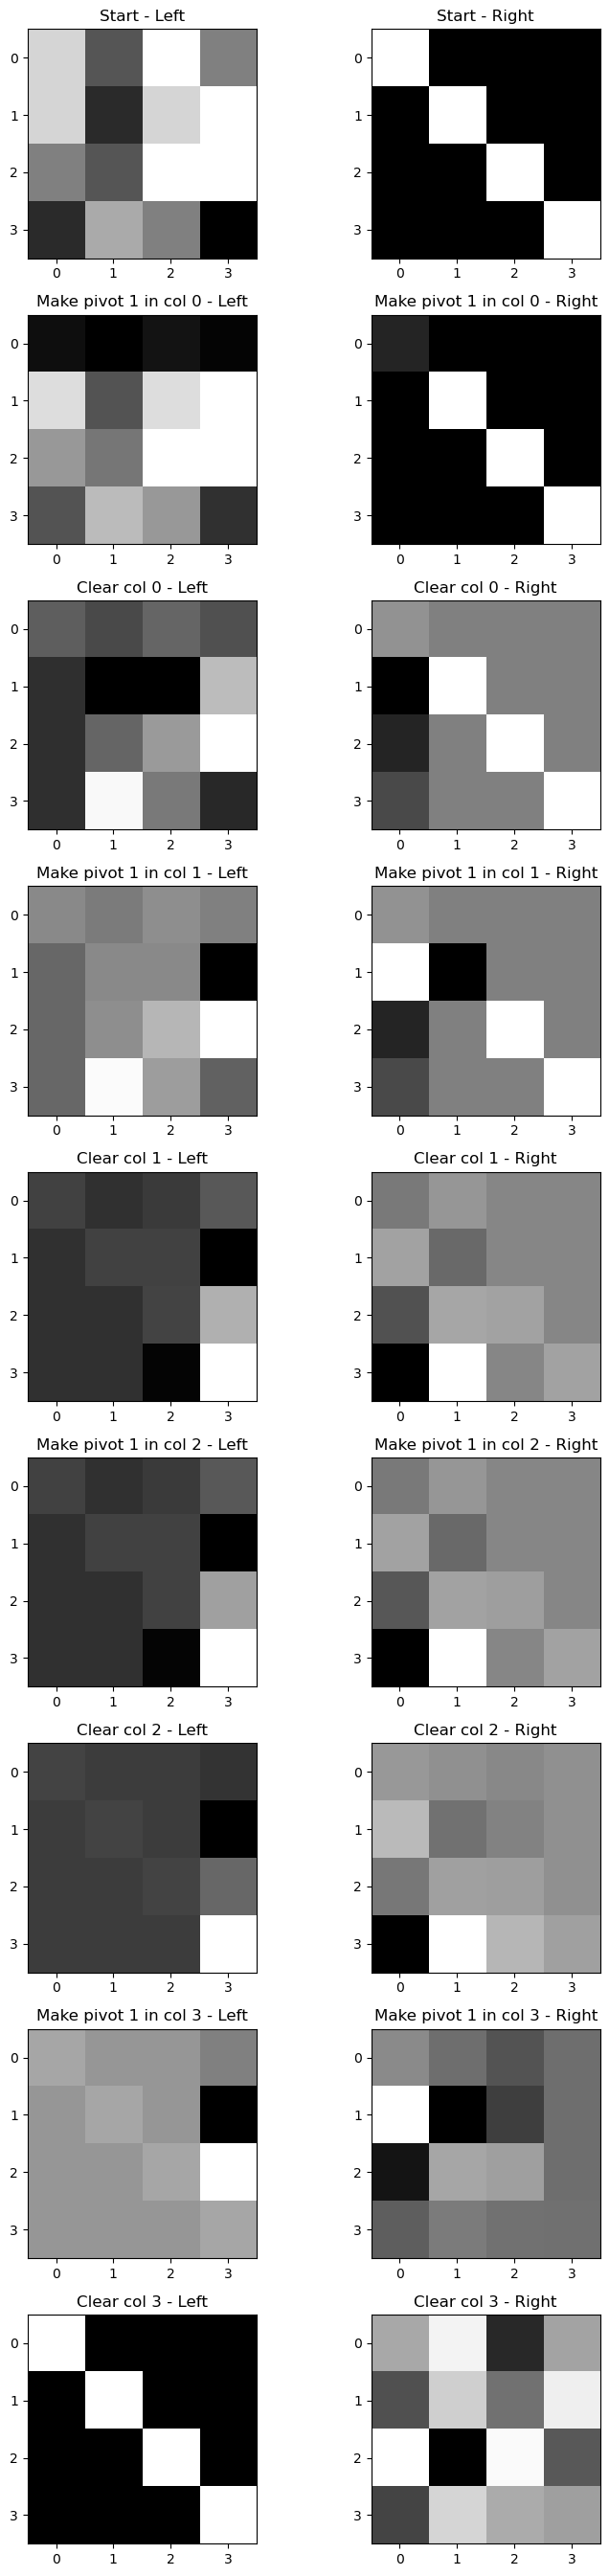

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# make random results repeatable
np.random.seed(42)

# create a random full-rank square matrix
n = 4
A = np.random.randint(1, 10, size=(n, n)).astype(float)

# keep trying until matrix is full rank
while np.linalg.matrix_rank(A) < n:
    A = np.random.randint(1, 10, size=(n, n)).astype(float)

# identity matrix
I = np.eye(n)

# make copies so original A stays unchanged
left = A.copy()
right = I.copy()

# store steps for plotting
steps = [(left.copy(), right.copy(), "Start")]

# Gauss-Jordan elimination
for col in range(n):
    # get pivot
    pivot = left[col, col]
    
    # if pivot is 0, swap with a lower row
    if pivot == 0:
        for r in range(col + 1, n):
            if left[r, col] != 0:
                left[[col, r]] = left[[r, col]]
                right[[col, r]] = right[[r, col]]
                break
        pivot = left[col, col]
    
    # scale row so pivot becomes 1
    left[col] = left[col] / pivot
    right[col] = right[col] / pivot
    steps.append((left.copy(), right.copy(), f"Make pivot 1 in col {col}"))
    
    # make all other values in this column 0
    for r in range(n):
        if r != col:
            factor = left[r, col]
            left[r] = left[r] - factor * left[col]
            right[r] = right[r] - factor * right[col]
    
    steps.append((left.copy(), right.copy(), f"Clear col {col}"))

# print results
print("Original matrix A:")
print(A)

print("\nInverse of A from algorithm:")
print(right)

print("\nCheck with numpy:")
print(np.linalg.inv(A))

print("\nA multiplied by inverse:")
print(np.round(A @ right, 5))

# plot steps similar to the figure
num_steps = len(steps)
fig, axes = plt.subplots(num_steps, 2, figsize=(8, 3 * num_steps))

if num_steps == 1:
    axes = np.array([axes])

for i, (left_mat, right_mat, title) in enumerate(steps):
    axes[i, 0].imshow(left_mat, cmap="gray")
    axes[i, 0].set_title(f"{title} - Left")
    axes[i, 0].set_xticks(range(n))
    axes[i, 0].set_yticks(range(n))
    
    axes[i, 1].imshow(right_mat, cmap="gray")
    axes[i, 1].set_title(f"{title} - Right")
    axes[i, 1].set_xticks(range(n))
    axes[i, 1].set_yticks(range(n))

plt.tight_layout()
plt.show()

### Problem 7 (15 pts)

The LIVE EVIL rule applies to the inverse of multiplied matrices. Test this in code by creating two square full-rank matrices $A$ and $B$, then use Euclidean distance to compare:
1. $(AB)^{-1}$ 
2. $A^{-1}B^{-1}$
3. $B^{-1}A^{-1}$

Before starting to code, make a prediction about which results will be equal. Print out your results using formatting like the following:

```
Distance between (AB)^-1 and (A^-1)(B^-1) is ___
Distance between (AB)^-1 and (B^-1)(A^-1) is ___
Distance between (A^-1)(B^-1) and (B^-1)(A^-1) is ___
```

#### Grading: 
5 points per comparision. 

### Prediction

I think (AB)^-1 will be the same as B^-1 A^-1, but not the same as A^-1 B^-1.

This is because with matrices the order matters when you multiply them. When you take the inverse of a product, the order flips. So (AB)^-1 should match B^-1 A^-1. Because of that I expect the distance between those two to be very close to 0, while the others will be bigger.

In [18]:
import numpy as np

# prediction:
# (AB)^-1 should be equal to B^-1 A^-1
# it should not be equal to A^-1 B^-1 in general

np.random.seed(42)

# make two random full-rank square matrices
n = 3
A = np.random.randint(1, 10, size=(n, n)).astype(float)
B = np.random.randint(1, 10, size=(n, n)).astype(float)

# keep trying until both are full rank
while np.linalg.matrix_rank(A) < n:
    A = np.random.randint(1, 10, size=(n, n)).astype(float)

while np.linalg.matrix_rank(B) < n:
    B = np.random.randint(1, 10, size=(n, n)).astype(float)

# compute inverses
AB_inv = np.linalg.inv(A @ B)
A_inv_B_inv = np.linalg.inv(A) @ np.linalg.inv(B)
B_inv_A_inv = np.linalg.inv(B) @ np.linalg.inv(A)

# Euclidean distances
dist_1 = np.linalg.norm(AB_inv - A_inv_B_inv)
dist_2 = np.linalg.norm(AB_inv - B_inv_A_inv)
dist_3 = np.linalg.norm(A_inv_B_inv - B_inv_A_inv)

print("Distance between (AB)^-1 and (A^-1)(B^-1) is", dist_1)
print("Distance between (AB)^-1 and (B^-1)(A^-1) is", dist_2)
print("Distance between (A^-1)(B^-1) and (B^-1)(A^-1) is", dist_3)

Distance between (AB)^-1 and (A^-1)(B^-1) is 15.644504355489383
Distance between (AB)^-1 and (B^-1)(A^-1) is 8.879338333810442e-14
Distance between (A^-1)(B^-1) and (B^-1)(A^-1) is 15.644504355489325
